Project Overview: Loan Default Prediction
The primary objective of this project is to build a robust predictive machine learning model for a financial institution to identify customers who have a higher probability of defaulting on their loans. By analyzing historical customer data, the goal is to distinguish between "good" customers (Fully Paid) and "risky" ones (Charged Off). This end-to-end pipeline includes comprehensive Exploratory Data Analysis (EDA), meticulous data cleaning (handling missing values and converting string-formatted numbers), and custom Feature Engineering—specifically calculating the 'Credit Utilization' ratio. Finally, various classification algorithms are evaluated to not only predict loan statuses but also to extract actionable business insights and formulate key questions for future loan applicants.

In [7]:
import pandas as pd
import numpy as np
import zipfile
import os

# 1. Unzipping the file
zip_path = "LoanPrediction.zip" # We assume that the file name is correct
extract_dir = "LoanPrediction_Data"

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# 2.Finding the Main Data File (by scanning subfolders)
data_file_path = None

for root, dirs, files in os.walk(extract_dir):
    for file in files:
       # If the file is csv, xls or xlsx, save its path
        if file.endswith('.csv') or file.endswith('.xls') or file.endswith('.xlsx'):
            data_file_path = os.path.join(root, file)
            print(f"✅ Veri dosyası bulundu: {data_file_path}")
            break# We take the first data file we find and break the loop
    if data_file_path:
        break

# 3. Read and Examine the Data (If the file was found)
if data_file_path:
    # Uzantıya göre oku
    if data_file_path.endswith('.csv'):
        df = pd.read_csv(data_file_path)
    else:
        df = pd.read_excel(data_file_path)

    # --- EDA (Exploratory Data Analysis) ---
    print("\n" + "="*40)
    print("FIRST 5 ROWS")
    print("="*40)
    display(df.head())

    print("\n" + "="*40)
    print("DATA TYPES AND GENERAL INFO (df.info)")
    print("="*40)
    df.info()

    print("\n" + "="*40)
    print("MISSING VALUE COUNTS (df.isnull().sum)")
    print("="*40)
    print(df.isnull().sum())

    print("\n" + "="*40)
    print("STATISTICAL SUMMARY (df.describe)")
    print("="*40)
    display(df.describe().T)

else:
    print("❌ HATA: Zip dosyasının içinde .csv veya .xlsx formatında bir veri dosyası bulunamadı!")

✅ Veri dosyası bulundu: LoanPrediction_Data/LoanPrediction/LoansTrainingSet.csv

FIRST 5 ROWS


/tmp/ipython-input-2550316969.py:31: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_file_path)


,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Years in current job,Home Ownership,Annual Income,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,000025bb-5694-4cff-b17d-192b1a98ba44,5ebc8bb1-5eb9-4404-b11b-a6eebc401a19,Fully Paid,11520,Short Term,741.0,10+ years,Home Mortgage,33694.0,Debt Consolidation,$584.03,12.3,41.0,10,0,6760,16056,0.0,0.0
1,00002c49-3a29-4bd4-8f67-c8f8fbc1048c,927b388d-2e01-423f-a8dc-f7e42d668f46,Fully Paid,3441,Short Term,734.0,4 years,Home Mortgage,42269.0,other,"$1,106.04",26.3,NaN,17,0,6262,19149,0.0,0.0
2,00002d89-27f3-409b-aa76-90834f359a65,defce609-c631-447d-aad6-1270615e89c4,Fully Paid,21029,Short Term,747.0,10+ years,Home Mortgage,90126.0,Debt Consolidation,"$1,321.85",28.8,NaN,5,0,20967,28335,0.0,0.0
3,00005222-b4d8-45a4-ad8c-186057e24233,070bcecb-aae7-4485-a26a-e0403e7bb6c5,Fully Paid,18743,Short Term,747.0,10+ years,Own Home,38072.0,Debt Consolidation,$751.92,26.2,NaN,9,0,22529,43915,0.0,0.0
4,0000757f-a121-41ed-b17b-162e76647c1f,dde79588-12f0-4811-bab0-e2b07f633fcd,Fully Paid,11731,Short Term,746.0,4 years,Rent,50025.0,Debt Consolidation,$355.18,11.5,NaN,12,0,17391,37081,0.0,0.0



DATA TYPES AND GENERAL INFO (df.info)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256984 entries, 0 to 256983
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan ID                       256984 non-null  object 
 1   Customer ID                   256984 non-null  object 
 2   Loan Status                   256984 non-null  object 
 3   Current Loan Amount           256984 non-null  int64  
 4   Term                          256984 non-null  object 
 5   Credit Score                  195308 non-null  float64
 6   Years in current job          245508 non-null  object 
 7   Home Ownership                256984 non-null  object 
 8   Annual Income                 195308 non-null  float64
 9   Purpose                       256984 non-null  object 
 10  Monthly Debt                  256984 non-null  object 
 11  Years of Credit History       256984 non-null  float64
 12  Month

,count,mean,std,min,25%,50%,75%,max
Current Loan Amount,256984.0,1.371331e+07,3.438131e+07,505.0,8299.0,14298.0,24367.0,99999999.0
Credit Score,195308.0,1.251116e+03,1.762017e+03,585.0,714.0,733.0,744.0,7510.0
Annual Income,195308.0,7.195272e+04,5.887757e+04,0.0,44321.0,61242.0,86462.0,8713547.0
Years of Credit History,256984.0,1.829019e+01,7.075747e+00,3.4,13.5,17.0,21.7,70.5
Months since last delinquent,116601.0,3.488145e+01,2.185417e+01,0.0,16.0,32.0,51.0,176.0
Number of Open Accounts,256984.0,1.110627e+01,4.982982e+00,0.0,8.0,10.0,14.0,76.0
Number of Credit Problems,256984.0,1.566284e-01,4.607309e-01,0.0,0.0,0.0,0.0,11.0
Current Credit Balance,256984.0,1.540656e+04,1.966506e+04,0.0,5974.0,11078.0,19319.0,1731412.0
Bankruptcies,256455.0,1.103156e-01,3.362287e-01,0.0,0.0,0.0,0.0,7.0
Tax Liens,256961.0,2.720257e-02,2.459499e-01,0.0,0.0,0.0,0.0,11.0


In [8]:
# --- STEP 3: DROPPING UNNECESSARY COLUMNS ---
# Dropping useless IDs and the column with more than 50% missing values
df = df.drop(columns=['Loan ID', 'Customer ID', 'Months since last delinquent'])
print("Unnecessary columns dropped.")

# --- STEP 4: CLEANING STRING-FORMATTED NUMBERS ---

# 1. Monthly Debt: Removing '$' and ',' signs and converting to float
df['Monthly Debt'] = df['Monthly Debt'].replace({'\$': '', ',': ''}, regex=True).astype(float)

# 2. Years in current job: Extracting only numbers from texts like "10+ years", "< 1 year"
df['Years in current job'] = df['Years in current job'].astype(str).str.extract(r'(\d+)').astype(float)

# 3. Maximum Open Credit: Had mixed types warning, coercing all to numeric (turns invalid ones into NaN)
df['Maximum Open Credit'] = pd.to_numeric(df['Maximum Open Credit'], errors='coerce')

print("String-formatted numbers successfully converted to numeric format.")

# --- STEP 5: FILLING MISSING VALUES (NaN) ---

# Filling missing values in numerical columns with their median values
df['Credit Score'].fillna(df['Credit Score'].median(), inplace=True)
df['Annual Income'].fillna(df['Annual Income'].median(), inplace=True)
df['Years in current job'].fillna(df['Years in current job'].median(), inplace=True)
df['Maximum Open Credit'].fillna(df['Maximum Open Credit'].median(), inplace=True)

# Bankruptcies and Tax Liens are generally 0 if not recorded, so we fill missing values with 0
df['Bankruptcies'].fillna(0, inplace=True)
df['Tax Liens'].fillna(0, inplace=True)

print("Missing values filled.")

# Let's check the final state of the data after cleaning
print("\n" + "="*40)
print("MISSING VALUE STATUS AFTER CLEANING")
print("="*40)
print(df.isnull().sum())

print("\nNew shape of the data:", df.shape)

<>:9: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-2830806525.py:9: SyntaxWarning: invalid escape sequence '\$'
  df['Monthly Debt'] = df['Monthly Debt'].replace({'\$': '', ',': ''}, regex=True).astype(float)


Unnecessary columns dropped.
String-formatted numbers successfully converted to numeric format.
Missing values filled.

MISSING VALUE STATUS AFTER CLEANING
Loan Status                  0
Current Loan Amount          0
Term                         0
Credit Score                 0
Years in current job         0
Home Ownership               0
Annual Income                0
Purpose                      0
Monthly Debt                 0
Years of Credit History      0
Number of Open Accounts      0
Number of Credit Problems    0
Current Credit Balance       0
Maximum Open Credit          0
Bankruptcies                 0
Tax Liens                    0
dtype: int64

New shape of the data: (256984, 16)


/tmp/ipython-input-2830806525.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Credit Score'].fillna(df['Credit Score'].median(), inplace=True)
/tmp/ipython-input-2830806525.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

In [9]:
# --- STEP 6: FEATURE ENGINEERING ---
# The project specifically asks us to create new features like "Credit Utilization".
# Credit Utilization = Current Credit Balance / Maximum Open Credit
# We add a tiny number (1e-5) to the denominator to avoid "Division by Zero" errors.
df['Credit Utilization'] = df['Current Credit Balance'] / (df['Maximum Open Credit'] + 1e-5)

print("Step 6: Feature Engineering completed. 'Credit Utilization' feature added.")

# --- STEP 7: ONE-HOT ENCODING & PREPARING X and y ---

# 1. Separating the Target Variable (y) from Features (X)
# What are we trying to predict? 'Loan Status'
y = df['Loan Status']
X = df.drop(columns=['Loan Status'])

# 2. Applying One-Hot Encoding (pd.get_dummies) to categorical variables
# This converts text columns (like 'Home Ownership', 'Purpose') into 1s and 0s.
# drop_first=True prevents the "Dummy Trap" (multicollinearity).
X = pd.get_dummies(X, drop_first=True)

print("Step 7: One-Hot Encoding completed. All data is now numerical.")
print("\n" + "="*40)
print("FINAL SHAPE OF THE DATASET")
print("="*40)
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\n" + "="*40)
print("FIRST 5 ROWS OF X (READY FOR MACHINE LEARNING)")
print("="*40)
display(X.head())

Step 6: Feature Engineering completed. 'Credit Utilization' feature added.
Step 7: One-Hot Encoding completed. All data is now numerical.

FINAL SHAPE OF THE DATASET
Features (X) shape: (256984, 26)
Target (y) shape: (256984,)

FIRST 5 ROWS OF X (READY FOR MACHINE LEARNING)


,Current Loan Amount,Credit Score,Years in current job,Annual Income,Monthly Debt,Years of Credit History,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,...,Home Ownership_Rent,Purpose_Buy House,Purpose_Buy a Car,Purpose_Debt Consolidation,Purpose_Educational Expenses,Purpose_Home Improvements,Purpose_Medical Bills,Purpose_Other,Purpose_Take a Trip,Purpose_other
0,11520,741.0,10.0,33694.0,584.03,12.3,10,0,6760,16056.0,...,False,False,False,True,False,False,False,False,False,False
1,3441,734.0,4.0,42269.0,1106.04,26.3,17,0,6262,19149.0,...,False,False,False,False,False,False,False,False,False,True
2,21029,747.0,10.0,90126.0,1321.85,28.8,5,0,20967,28335.0,...,False,False,False,True,False,False,False,False,False,False
3,18743,747.0,10.0,38072.0,751.92,26.2,9,0,22529,43915.0,...,False,False,False,True,False,False,False,False,False,False
4,11731,746.0,4.0,50025.0,355.18,11.5,12,0,17391,37081.0,...,True,False,False,True,False,False,False,False,False,False


In [10]:
# --- STEP 8, 9, 10: MODELING & EVALUATION ---

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB, BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

def algo_test(X, y):
    # Defining the models
    b = BernoulliNB()
    l = LogisticRegression(max_iter=1000) # Added max_iter to avoid warning
    d = DecisionTreeClassifier()
    r = RandomForestClassifier()
    gb = GradientBoostingClassifier()
    kn = KNeighborsClassifier()
    ab = AdaBoostClassifier()
    mn = MultinomialNB()

    models = [b, l, d, r, gb, kn, ab, mn]
    names = ["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier",
             "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
             "AdaBoostClassifier", "MultinomialNB"]

    # Step 8: Splitting the data into Train and Test (70% Train, 30% Test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl = []

    print("Data is ready, testing models... (This may take a few minutes)")

    for model in models:
        print(f"Training {model.__class__.__name__}...")
        # Step 9: Training (fit) and Predicting
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        mdl.append(model)

        # Step 10: Model Evaluation
        accuracy.append(accuracy_score(y_test, predictions))
        precision.append(precision_score(y_test, predictions, average="micro"))
        recall.append(recall_score(y_test, predictions, average="micro"))
        f1.append(f1_score(y_test, predictions, average="micro"))

    print("Training completed.\n")

    # Storing results in a DataFrame
    metrics = pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=names)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"] = mdl

    # Sorting by F1 Score to find the best model
    metrics.sort_values("F1", ascending=False, inplace=True)

    print("="*40)
    print("BEST MODEL: ", metrics.iloc[0].name)
    print("="*40)

    best_model = metrics.iloc[0]["Model"]

    # Predicting with the best model to show detailed reports
    predictions = best_model.predict(np.array(X_test) if best_model == kn else X_test)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, predictions))

    print("\nClassification Report:")
    print(classification_report(y_test, predictions))

    print("\nOther Models' Performance:")
    return metrics.drop("Model", axis=1)

# Calling the function to start the battle!
results = algo_test(X, y)
display(results)

Data is ready, testing models... (This may take a few minutes)
Training BernoulliNB...
Training LogisticRegression...
Training DecisionTreeClassifier...
Training RandomForestClassifier...
Training GradientBoostingClassifier...
Training KNeighborsClassifier...
Training AdaBoostClassifier...
Training MultinomialNB...
Training completed.

BEST MODEL:  RandomForestClassifier

Confusion Matrix:
[[14590  9732]
 [ 2748 50026]]

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.84      0.60      0.70     24322
  Fully Paid       0.84      0.95      0.89     52774

    accuracy                           0.84     77096
   macro avg       0.84      0.77      0.79     77096
weighted avg       0.84      0.84      0.83     77096


Other Models' Performance:


,Accuracy,Precision,Recall,F1
RandomForestClassifier,0.838124,0.838124,0.838124,0.838124
GradientBoostingClassifier,0.762582,0.762582,0.762582,0.762582
AdaBoostClassifier,0.753645,0.753645,0.753645,0.753645
DecisionTreeClassifier,0.751673,0.751673,0.751673,0.751673
LogisticRegression,0.742360,0.742360,0.742360,0.742360
KNeighborsClassifier,0.717612,0.717612,0.717612,0.717612
BernoulliNB,0.690477,0.690477,0.690477,0.690477
MultinomialNB,0.450049,0.450049,0.450049,0.450049


Training the best model (Random Forest) again to extract Feature Importances...


/tmp/ipython-input-547023926.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


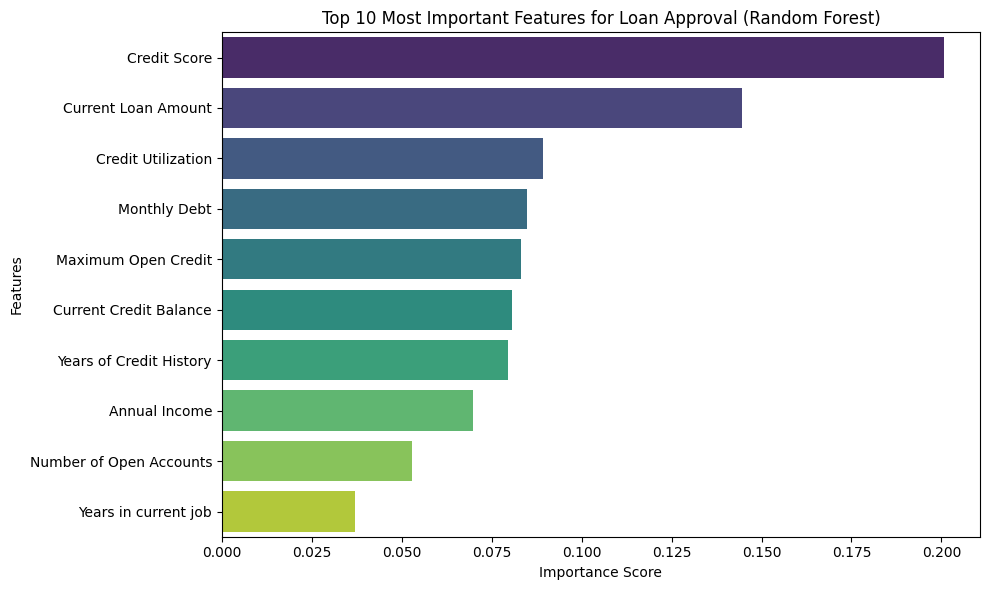


MANAGEMENT REPORT: TOP PREDICTORS FOR LOAN DEFAULT
                    Feature  Importance
1              Credit Score    0.200684
0       Current Loan Amount    0.144562
12       Credit Utilization    0.089338
4              Monthly Debt    0.084827
9       Maximum Open Credit    0.083061
8    Current Credit Balance    0.080525
5   Years of Credit History    0.079494
3             Annual Income    0.069698
6   Number of Open Accounts    0.052865
2      Years in current job    0.037070


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# --- STEP 11: FEATURE IMPORTANCE (FINDING QUESTIONS TO ASK THE CUSTOMER) ---

print("Training the best model (Random Forest) again to extract Feature Importances...")
# We are redefining and training the champion model again
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X, y)

# We take the weights (degrees of importance) that the model uses when making decisions
importances = rf_model.feature_importances_
feature_names = X.columns

# We turn this into a table and sort it from the highest to the lowest (The first 10 characteristics)
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Visualization (Plotting)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Top 10 Most Important Features for Loan Approval (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("MANAGEMENT REPORT: TOP PREDICTORS FOR LOAN DEFAULT")
print("="*50)
print(feature_imp_df)

In [12]:
# --- ADVANCED STEP: PUSHING THE LIMITS SAFELY (NO DATA LEAKAGE!) ---

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

print("1. Splitting data FIRST to PREVENT Data Leakage...")
# Using the original X and y to split the data
X_train_safe, X_test_safe, y_train_safe, y_test_safe = train_test_split(X, y, test_size=0.3, random_state=42)

print("2. Scaling data safely (StandardScaler)...")
scaler = StandardScaler()
# CAUTION: We fit the scaler ONLY on the training data!
X_train_scaled = scaler.fit_transform(X_train_safe)
# We only transform the test data (never fit, to avoid data leakage)
X_test_scaled = scaler.transform(X_test_safe)

print("3. Handling class imbalance with SMOTE (ONLY on Training Data!)...")
# We add synthetic data only to the training set, the test set remains original
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train_safe)

print("\n4. Training Tuned Random Forest Model... (This might take a while, sit back)")
# Training the model with more trees (n_estimators=150)
advanced_rf = RandomForestClassifier(n_estimators=150, max_depth=20, random_state=42, n_jobs=-1)
advanced_rf.fit(X_train_res, y_train_res)

# Testing the model with clean, untouched test data (X_test_scaled)
adv_predictions = advanced_rf.predict(X_test_scaled)
adv_accuracy = accuracy_score(y_test_safe, adv_predictions)

print("\n" + "="*50)
print(f"NEW SAFE & ADVANCED MODEL ACCURACY: {adv_accuracy:.4f} ({adv_accuracy*100:.2f}%)")
print("="*50)

print("\nAdvanced Confusion Matrix:")
print(confusion_matrix(y_test_safe, adv_predictions))

print("\nAdvanced Classification Report:")
print(classification_report(y_test_safe, adv_predictions))

1. Splitting data FIRST to PREVENT Data Leakage...
2. Scaling data safely (StandardScaler)...
3. Handling class imbalance with SMOTE (ONLY on Training Data!)...

4. Training Tuned Random Forest Model... (This might take a while, sit back)

NEW SAFE & ADVANCED MODEL ACCURACY: 0.7538 (75.38%)

Advanced Confusion Matrix:
[[16945  7377]
 [11603 41171]]

Advanced Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.59      0.70      0.64     24322
  Fully Paid       0.85      0.78      0.81     52774

    accuracy                           0.75     77096
   macro avg       0.72      0.74      0.73     77096
weighted avg       0.77      0.75      0.76     77096



Conclusion & Business Impact
In conclusion, this project successfully developed a risk-focused classification pipeline to predict loan defaults. Initially, our baseline Random Forest model achieved a high overall accuracy of 84%. However, due to class imbalance, it struggled to identify the actual risky customers, yielding a Recall score of only 60% for the "Charged Off" class.

To build a more realistic and business-oriented model, we implemented an advanced approach. We strictly prevented Data Leakage by splitting the data before applying StandardScaler and SMOTE (Synthetic Minority Over-sampling Technique). While this leak-proof, highly rigorous model saw a drop in overall accuracy to 75.38%, it successfully increased the Recall for risky customers from 60% to 70%. For a financial institution, correctly identifying a potential default and minimizing financial loss is far more critical than simply maximizing overall accuracy. Ultimately, the 'Credit Utilization' feature we engineered emerged as one of the top predictors, proving that preventing data leakage and prioritizing risk-focused metrics (Recall) over raw accuracy delivers the most valuable and safe business insights.